# Fine-tune BERTopic (UMAP/HDBSCAN) parameters

In [ ]:
import time

import gensim
import nltk
import numpy as np
from dask import dataframe as dd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

from custom_stopwords import custom_stopwords

nltk.download('stopwords')
stop_words = set(nltk.corpus.stopwords.words('english'))
stop_words = list(stop_words.union(custom_stopwords))

df = dd.read_parquet(f"artifacts/Preprocessing/arxiv-metadata-cleaned_BERTopic.parquet")

corpus = df["title"].compute().astype(str).tolist()

print(corpus[:5])
print(len(corpus))
embeddings = np.load(f"artifacts/BERTopic/bertopic-title-1632186-embeddings.npy")

for i in (7,15):
    print(f"=== BERTopic with n_components={i} ===")
    print("  Initializing BERTopic model...")
    topic_model = BERTopic(
        verbose=True,
        embedding_model=None, # embeddings are generated/loaded separately above
        umap_model=UMAP(
            n_components=i, # default 2
            min_dist=0.0, # default 0.1
            metric="cosine",
            random_state=2718
        ),
        hdbscan_model=HDBSCAN(
            min_cluster_size=3000,
            min_samples=300,
            prediction_data=True
        ),
        vectorizer_model=CountVectorizer(
            stop_words=stop_words,
            ngram_range=(1,2),
            min_df=10, # ignore terms that appear in fewer than 10 documents
            max_df=0.9, # ignore terms that appear in more than 90% of documents
        )
    )
    print("  Fitting BERTopic model to generate topics and probabilities...")
    tick = time.time()
    topics, probs = topic_model.fit_transform(corpus, embeddings)
    tack = time.time()
    print(f"  BERTopic fitting completed in {tack - tick:.2f} seconds.")

    all_topics = topic_model.get_topics()
    # print all topics and their top 10 words
    for topic in range(len(all_topics)-1): # -1 to skip outliers
        print(f"Topic {topic}: {[word for word, _ in topic_model.get_topic(topic)[:10]]}")

    feature_names = topic_model.vectorizer_model.get_feature_names_out()
    print(f"  Number of feature names: {len(feature_names)}")

    cleaned_corpus = topic_model._preprocess_text(corpus) 
    print(f"  CLEANED CORPUS with {len(cleaned_corpus)} documents:")
    print(cleaned_corpus[:5])

    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()

    words = vectorizer.get_feature_names_out()

    print(f"  {len(words)} WORDS")
    print(words[:20])

    tokens = [analyzer(doc) for doc in cleaned_corpus]
    print(f"  TOKENS from {len(tokens)} documents:")
    print(len(tokens))
    print(tokens[:5])

    dictionary = gensim.corpora.Dictionary(tokens)
    print("  DICTIONARY:")
    print(dictionary)

    tokenized_corpus = [dictionary.doc2bow(token) for token in tokens]
    print(f"  TOKENIZED CORPUS with {len(tokenized_corpus)} documents:")
    print(tokenized_corpus[:5])

    topic_words = []
    for topic in range(len(set(topics))-topic_model._outliers):
        words = list(zip(*topic_model.get_topic(topic)))[0]
        words = [word for word in words if word in dictionary.token2id]
        topic_words.append(words)
    topic_words = [words for words in topic_words if len(words) > 0]
    print(f"  WORDS in {len(topic_words)} topics:")
    print(topic_words[:5])

    coherence_model = gensim.models.CoherenceModel(
        topics=topic_words, # list of list of str
        texts=tokens, # tokenized texts
        corpus=tokenized_corpus, # corpus in BoW format
        dictionary=dictionary,
    )

    print("  Calculating coherence...")
    coherence = coherence_model.get_coherence()

    print(f'  Coherence: {coherence}')
    print("-"*50)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/azureuser/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['dynamical analysis of brans-dicke universe with inverse power-law effective potential', 'toporesnet: a hybrid deep learning architecture and its application to skin lesion classification', 'pyramid: a general framework for distributed similarity search', 'ziele und m\\"oglichkeiten des einsatzes von knowledge-maps in mathematik-historischen veranstaltungen', 'quiver mutations, seiberg duality and machine learning']
1632186
=== BERTopic with n_components=7 ===
  Initializing BERTopic model...
  Fitting BERTopic model to generate topics and probabilities...


2026-05-21 12:40:21,207 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 13:20:05,197 - BERTopic - Dimensionality - Completed ✓
2026-05-21 13:20:05,223 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 13:25:18,120 - BERTopic - Cluster - Completed ✓
2026-05-21 13:25:18,216 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 13:25:35,450 - BERTopic - Representation - Completed ✓


  BERTopic fitting completed in 2715.04 seconds.
Topic 0: ['equations', 'spaces', 'algebras', 'finite', 'surfaces', 'manifolds', 'operators', 'schrodinger', 'theorem', 'elliptic']
Topic 1: ['galaxies', 'galaxy', 'stars', 'stellar', 'star', 'formation', 'clusters', 'dwarf', 'galactic', 'dust']
Topic 2: ['quantum', 'entanglement', 'quantum systems', 'manybody', 'circuits', 'classical', 'quantum circuits', 'quantum computing', 'variational quantum', 'open quantum']
Topic 3: ['hall', 'magnetic', 'superconductivity', 'spin', 'topological', 'films', 'superconductors', 'superconducting', 'thin', 'metal']
Topic 4: ['collisions', 'qcd', 'decays', 'lhc', 'quark', 'higgs', 'tev', 'heavy', 'nuclear', 'decay']
Topic 5: ['language', 'language models', 'large language', 'reasoning', 'translation', 'machine translation', 'llms', 'language model', 'multilingual', 'llm']
Topic 6: ['mimo', 'wireless', 'communications', 'iot', 'beamforming', 'intelligent', '6g', '5g', 'access', 'channel estimation']
Topic

2026-05-21 13:30:31,762 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 14:12:09,184 - BERTopic - Dimensionality - Completed ✓
2026-05-21 14:12:09,254 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 14:20:02,817 - BERTopic - Cluster - Completed ✓
2026-05-21 14:20:02,922 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 14:20:20,606 - BERTopic - Representation - Completed ✓


  BERTopic fitting completed in 2990.39 seconds.
Topic 0: ['black', 'gravity', 'black hole', 'black holes', 'hole', 'holes', 'gravitational', 'gauge', 'theories', 'inflation']
Topic 1: ['galaxies', 'galaxy', 'stars', 'stellar', 'star', 'formation', 'clusters', 'dwarf', 'galactic', 'dust']
Topic 2: ['hall', 'magnetic', 'superconductivity', 'spin', 'films', 'superconducting', 'metal', 'thin', 'waals', 'der waals']
Topic 3: ['collisions', 'qcd', 'production', 'decays', 'lhc', 'quark', 'higgs', 'tev', 'heavy', 'nuclear']
Topic 4: ['quantum', 'entanglement', 'quantum systems', 'key', 'circuits', 'manybody', 'quantum circuits', 'quantum computing', 'open quantum', 'circuit']
Topic 5: ['curvature', 'surfaces', 'curves', 'manifolds', 'bundles', 'varieties', 'conjecture', 'polynomials', 'forms', 'moduli']
Topic 6: ['language', 'language models', 'large language', 'reasoning', 'translation', 'machine translation', 'llms', 'language model', 'multilingual', 'llm']
Topic 7: ['mimo', 'wireless', 'co

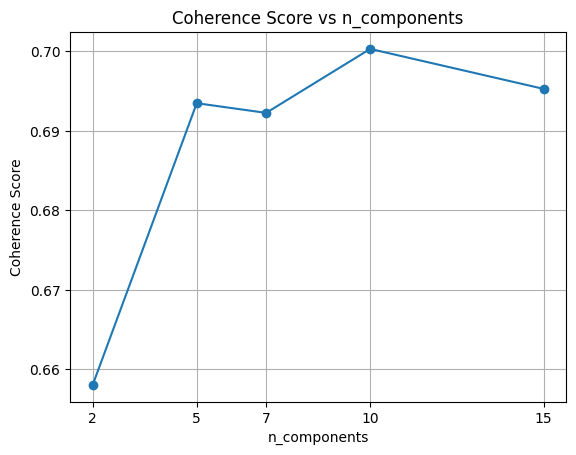

In [1]:
coherence_scores_per_n_components = [(2, 0.6580609362026186),(5, 0.6934768032501752), (7, 0.692259612612789), (10, 0.7003002359776682), (15, 0.6952774977510486)]

# plotting coherence scores
import matplotlib.pyplot as plt
n_components, coherence_scores = zip(*coherence_scores_per_n_components)
plt.plot(n_components, coherence_scores, marker='o')
plt.title('Coherence Score vs n_components')
plt.xlabel('n_components')
plt.ylabel('Coherence Score')
plt.xticks(n_components)
plt.grid()
plt.savefig("artifacts/BERTopic/bertopic-coherence-per-n-components.png")

plt.show()